In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from rebinding.fig_utils import save_fig, defaultStyle
defaultStyle(fs=14)

/tmp/ipykernel_28350/810007467.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bx.set_yticklabels(bx.get_yticklabels(), fontsize=18)
/tmp/ipykernel_28350/810007467.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  bx.set_yticklabels(bx.get_yticklabels(), fontsize=18)


Saving figure figSupp2


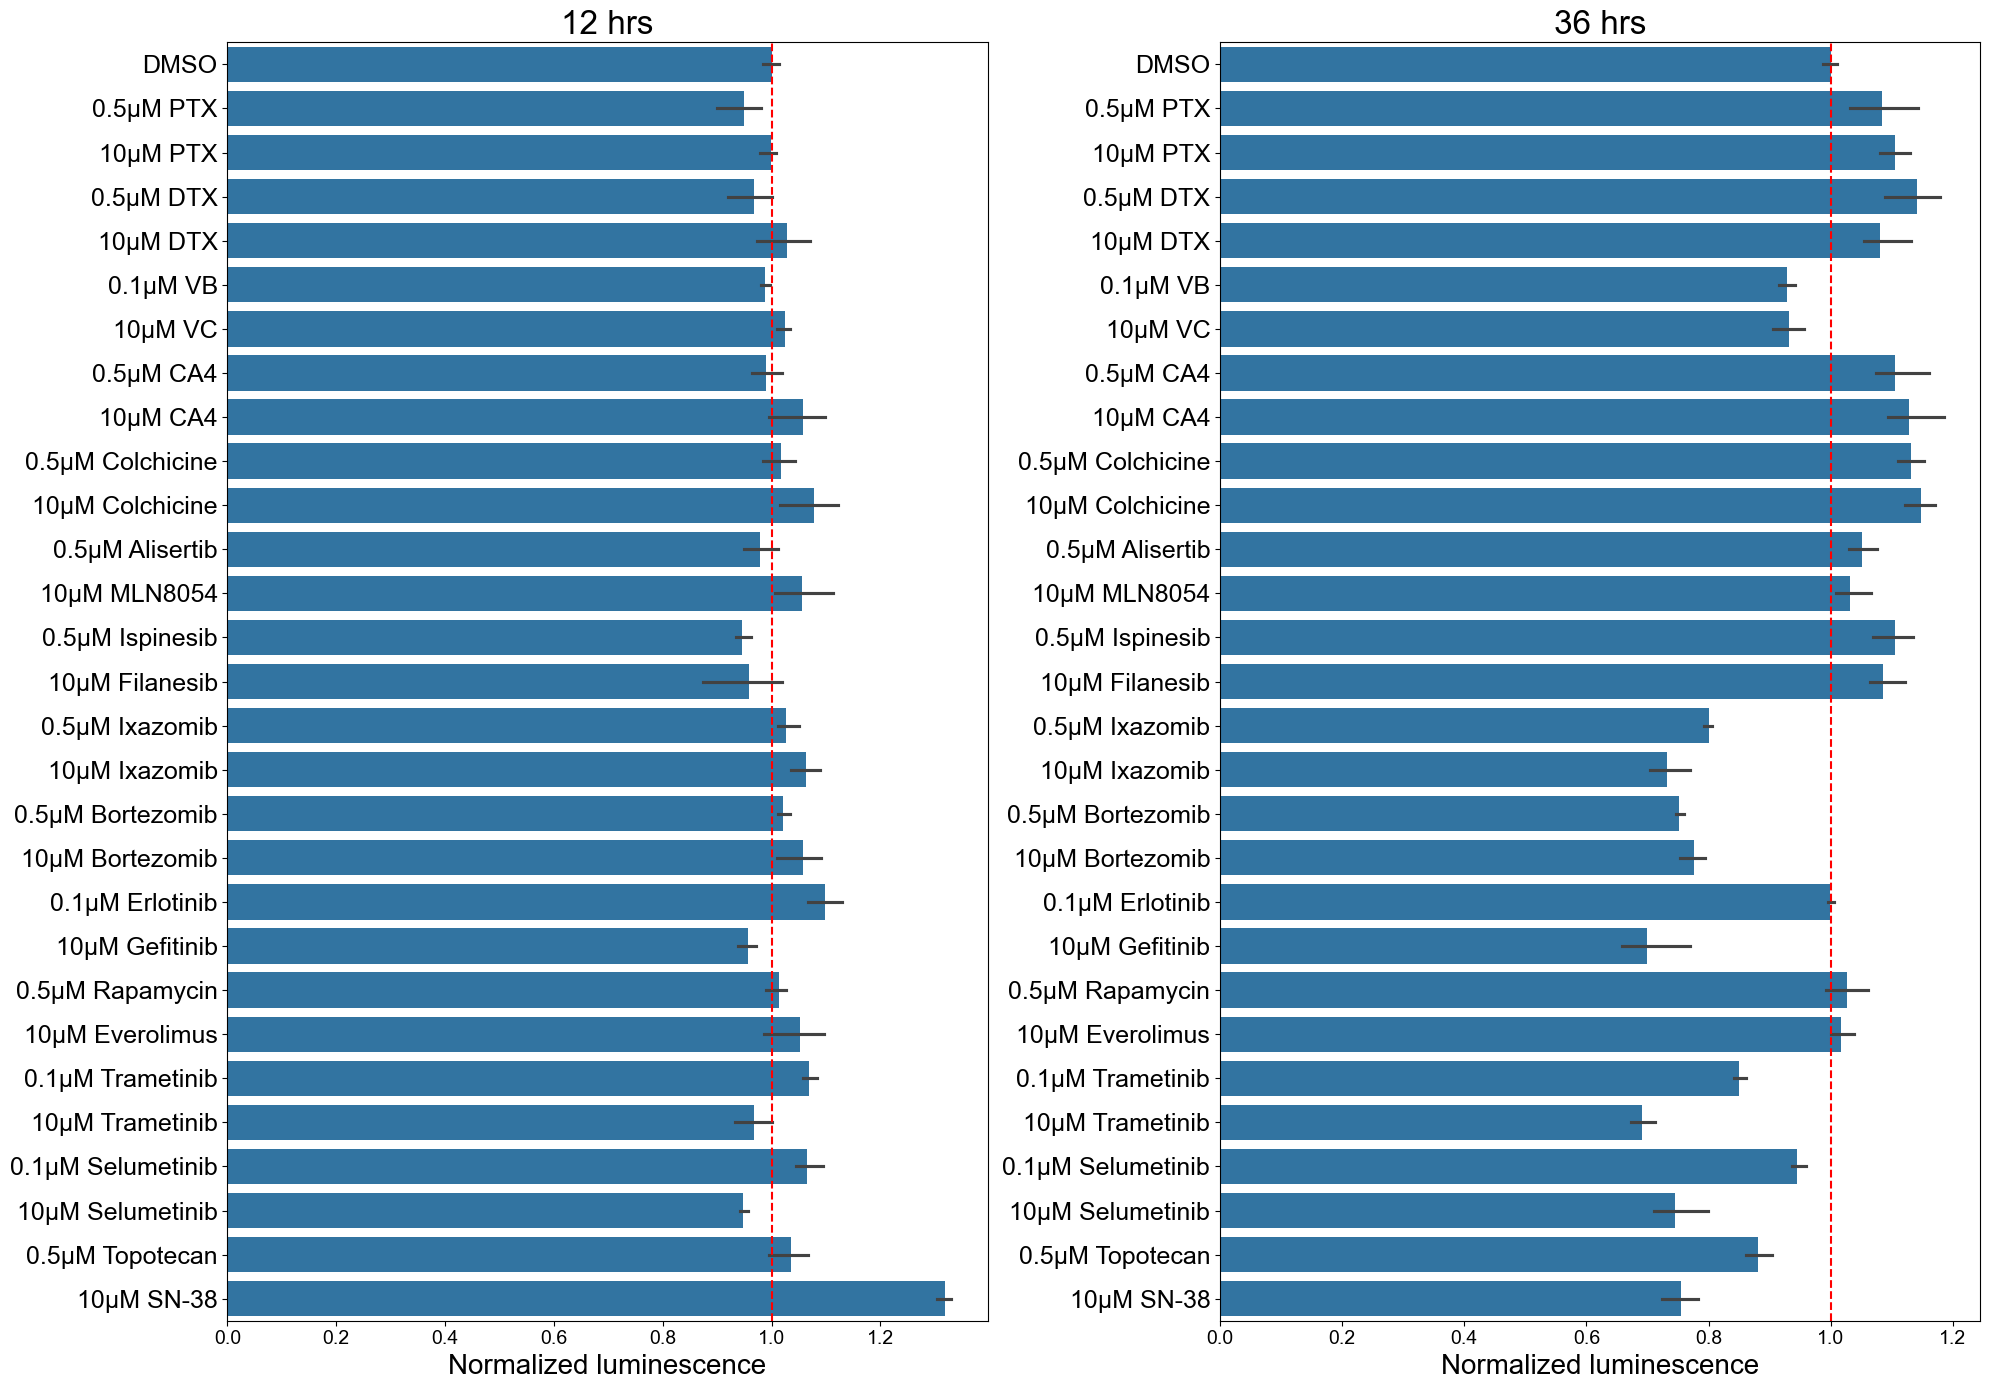

In [3]:
def load_data(sheet_name):
    data = pd.melt(
        pd.read_excel("../data/BYL246/BYL246_270.xlsx", sheet_name=sheet_name),
        id_vars="Condition",
        value_vars=["l1", "l2", "l3"],
        var_name="Rep",
        value_name="lum",
    )
    dmso_lum = data[data.Condition == "DMSO"].lum.mean()
    data.lum /= dmso_lum
    return data

order = pd.read_excel("../data/BYL246/BYL246_270.xlsx", sheet_name="order", header=None).values.flatten().tolist()

data_1 = pd.concat([load_data(f"Exp{i}_12h") for i in range(1, 4)])
data_2 = pd.concat([load_data(f"Exp{i}_36h") for i in range(1, 4)])
_, ax = plt.subplots(1, 2, figsize=(20, 14))
sns.barplot(data_1, y="Condition", x="lum", order=order, orient="h", ax=ax[0])
sns.barplot(data_2, y="Condition", x="lum", order=order, orient="h", ax=ax[1])
ax[0].set_title("12 hrs", fontsize=24)
ax[1].set_title("36 hrs", fontsize=24)
for bx in ax:
    bx.set_ylabel("")
    bx.set_xlabel("Normalized luminescence", fontsize=20)
    bx.axvline(1, ls="--", color="r")
    bx.set_yticklabels(bx.get_yticklabels(), fontsize=18)

save_fig("figSupp2", fmt="png", dpi=300)